# REHABELT (PREDICTION MODEL)

#### SETUPS

In [9]:
import os
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow Version: {tf.__version__}")
gpu_devices = tf.config.list_physical_devices('GPU')
if len(gpu_devices) > 0:
    print(f"GPU Detected: {gpu_devices}")
else:
    print("No GPU detected. Running in CPU mode (This is fine for this dataset size).")

# --- HYPERPARAMETERS ---
EPOCHS = 90            
BATCH_SIZE = 40        
LEARNING_RATE = 0.001   
NUM_CLASSES = 4         

# --- DATA PROCESSING SETTINGS ---
BASE_PATH = "Dataset"   
TARGET_FS = 50          
WINDOW_SEC = 2.0        
WINDOW_SIZE = int(TARGET_FS * WINDOW_SEC) 
STEP_SIZE = int(WINDOW_SIZE * 0.5)        

INPUT_SHAPE = (WINDOW_SIZE, 6) # (100 rows, 6 columns)

# Folders and Labels
FOLDERS = {0: 'raw_walk', 1: 'raw_sit_stand', 2: 'raw_supine_sit'}
LABELS = ["Walking", "Sit to Stand", "Supine to Sit", "Unrecognized"]


TensorFlow Version: 2.15.0
No GPU detected. Running in CPU mode (This is fine for this dataset size).


#### DATA LOADING & PREPROCESSING

In [10]:
X_all = []
y_all = []

print(f"\n Scanning dataset at: {os.path.abspath(BASE_PATH)}...")

if not os.path.exists(BASE_PATH):
    print(f"  CRITICAL ERROR: Folder '{BASE_PATH}' not found.")
    print("   Please ensure your CSV files are in: /Dataset/raw_walking/ etc.")
else:
    # 1. PROCESS REAL FILES
    for label_id, folder_name in FOLDERS.items():
        search_path = os.path.join(BASE_PATH, folder_name, "*.csv")
        files = glob.glob(search_path)
        print(f"   {folder_name}: Found {len(files)} files")
        
        for filepath in files:
            try:
                filename = os.path.basename(filepath)
                
                # KFALL OR CUSTOM 
                is_kfall = filename.upper().startswith('S') and 'T' in filename.upper()
                
                if is_kfall:
                    # K-FALL PROCESSING
                    df = pd.read_csv(filepath, skiprows=1)
                    data = df.iloc[:, 2:8].values 
                    data[:, 0:3] = data[:, 0:3] * 9.8 
                    new_len = int(len(data) / 2)
                    data = resample(data, new_len)
                else:
                    # CUSTOM DATA PROCESSING
                    df = pd.read_csv(filepath, header=None)
                    data = df.iloc[:, 0:6].values
                
                # WINDOWING 
                for i in range(0, len(data) - WINDOW_SIZE, STEP_SIZE):
                    window = data[i : i + WINDOW_SIZE]
                    if window.shape[0] == WINDOW_SIZE:
                        X_all.append(window)
                        y_all.append(label_id)
                        
            except Exception as e:
                print(f"   Error reading {filename}: {e}")

    X = np.array(X_all)
    y = np.array(y_all)

    # Final Check
    if len(X) == 0:
        print("\n ERROR: No data processed...")
    else:
        print(f"\n DATASET GENERATED!")
        print(f"   Total Windows: {X.shape[0]}")
        print(f"   Walking:       {np.sum(y == 0)}")
        print(f"   Sit-Stand:     {np.sum(y == 1)}")
        print(f"   Supine-Sit:    {np.sum(y == 2)}")
    


 Scanning dataset at: c:\Users\user\Downloads\rehabelt\Rehabelt\Dataset...
   raw_walk: Found 238 files
   raw_sit_stand: Found 229 files
   raw_supine_sit: Found 232 files

 DATASET GENERATED!
   Total Windows: 4560
   Walking:       2231
   Sit-Stand:     1002
   Supine-Sit:    1327


#### PREPARE FOR TRAINING

In [ ]:
if 'X' in locals() and len(X) > 0:
    print("Generating Synthetic Noise for 'Unrecognized' Class...")
    
    # FIX: Generate enough noise to match roughly 1/3rd of the real data
    # This prevents the model from ignoring the "Unrecognized" class
    n_existing = len(X)
    n_noise = int(n_existing / 3) 
    
    print(f"   -> Creating {n_noise} noise samples to balance the dataset...")

    X_noise_list = []
    y_noise_list = []
    
    for i in range(n_noise):
        # Variation 1: High Energy Chaos (e.g., Jumping/Shaking)
        if i % 2 == 0:
            noise_window = np.random.uniform(low=-15, high=15, size=(100, 6))
        
        # Variation 2: Low Energy Fidgeting (e.g., Scratching/Tapping)
        else:
            noise_window = np.random.uniform(low=-2, high=2, size=(100, 6))

        X_noise_list.append(noise_window)
        y_noise_list.append(3) # Class 3

    # Combine Real Data + Noise
    X_final = np.concatenate((X, np.array(X_noise_list)), axis=0)
    y_final = np.concatenate((y, np.array(y_noise_list)), axis=0)
    
    # Encode for 4 Classes
    y_encoded = to_categorical(y_final, 4) 
    
    # Split
    X_train, X_val, y_train, y_val = train_test_split(
        X_final, y_encoded, test_size=0.2, stratify=y_final, random_state=42
    )
    
    print(f"Data Ready! Total Samples: {len(X_final)}")
    print(f"(Walking/Sit/Supine + {n_noise} Unrecognized)")

else:
    print("ERROR: Variable 'X' not found. Please run the Data Loading cell above first.")

Generating Synthetic Noise for 'Unrecognized' Class...
   -> Creating 1520 noise samples to balance the dataset...
Data Ready! Total Samples: 6080
   (Walking/Sit/Supine + 1520 Unrecognized)


#### BUILD MODEL ARCHITECTURE (1D CNN)

In [12]:
model = Sequential([
    # Input: Flattens 100x6 -> 600 inputs. 
    # batch_input_shape=(1,...) fixes the 'EXPAND_DIMS' error.
    Flatten(batch_input_shape=(1, 100, 6)),

    # Hidden Layer 1: The Brain
    Dense(64, activation='relu'),
    Dropout(0.2),

    # Hidden Layer 2: Refinement
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    # Output Layer: 4 Buttons (Walk, Sit, Supine, Unrecognized)
    Dense(4, activation='softmax') 
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


#### MODEL TRAINING

In [13]:
print("\nStarting Training...")
history = model.fit(
    X_train, y_train, 
    epochs=90, 
    batch_size=40, 
    validation_data=(X_val, y_val), 
    verbose=1
)

model.save("rehabelt_model.keras")
print("Model Saved!")


Starting Training...
Epoch 1/90
122/122 [==============================] - 1s 2ms/step - loss: 2.1015 - accuracy: 0.7081 - val_loss: 0.3756 - val_accuracy: 0.8997
Epoch 2/90
122/122 [==============================] - 0s 1ms/step - loss: 0.6250 - accuracy: 0.8629 - val_loss: 0.2808 - val_accuracy: 0.9268
Epoch 3/90
122/122 [==============================] - 0s 1ms/step - loss: 0.4574 - accuracy: 0.8954 - val_loss: 0.2122 - val_accuracy: 0.9457
Epoch 4/90
122/122 [==============================] - 0s 1ms/step - loss: 0.3203 - accuracy: 0.9274 - val_loss: 0.1659 - val_accuracy: 0.9630
Epoch 5/90
122/122 [==============================] - 0s 1ms/step - loss: 0.2950 - accuracy: 0.9377 - val_loss: 0.1393 - val_accuracy: 0.9671
Epoch 6/90
122/122 [==============================] - 0s 1ms/step - loss: 0.2469 - accuracy: 0.9492 - val_loss: 0.1298 - val_accuracy: 0.9696
Epoch 7/90
122/122 [==============================] - 0s 2ms/step - loss: 0.1740 - accuracy: 0.9603 - val_loss: 0.0901 - val_a


 Model successfully saved as 'rehabelt_model.keras'


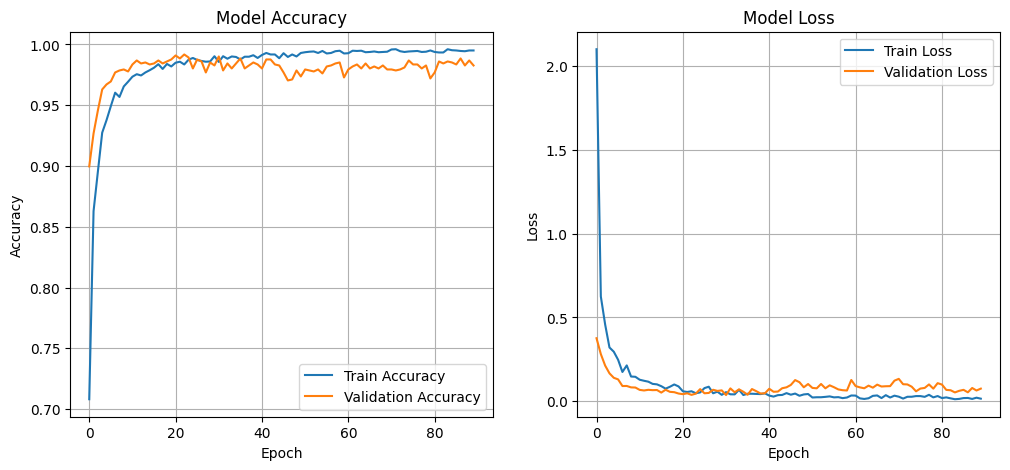


 Model Performance Report:
38/38 [==============================] - 0s 784us/step


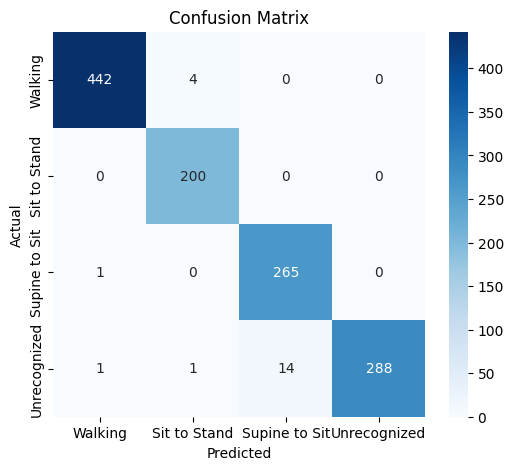

               precision    recall  f1-score   support

      Walking       1.00      0.99      0.99       446
 Sit to Stand       0.98      1.00      0.99       200
Supine to Sit       0.95      1.00      0.97       266
 Unrecognized       1.00      0.95      0.97       304

     accuracy                           0.98      1216
    macro avg       0.98      0.98      0.98      1216
 weighted avg       0.98      0.98      0.98      1216



In [14]:
        # Save model
        model_name = "rehabelt_model.keras"
        model.save(model_name)
        print(f"\n Model successfully saved as '{model_name}'")

        # Plot Accuracy
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Train Accuracy')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.title('Model Accuracy')
        plt.ylabel('Accuracy')
        plt.xlabel('Epoch')
        plt.legend()
        plt.grid(True)

        # Plot Loss
        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title('Model Loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend()
        plt.grid(True)
        
        plt.show()

        # Confusion Matrix
        print("\n Model Performance Report:")
        y_pred = np.argmax(model.predict(X_val), axis=1)
        y_true = np.argmax(y_val, axis=1)
        
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=LABELS, yticklabels=LABELS)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix')
        plt.show()

        print(classification_report(y_true, y_pred, target_names=LABELS))

### TESTING 


 Reading file: Dataset/raw_sit_stand/S06T13R05.csv...
   -> Detected: K-FALL format (Resampled & Converted)
   -> Analyzed 6 windows of movement...

 RESULT: Sit to Stand
 CONFIDENCE:    83.33%
Detailed Breakdown:
   Walking:      0.0%
   Sit to Stand: 83.3%
   Supine to Sit:16.7%


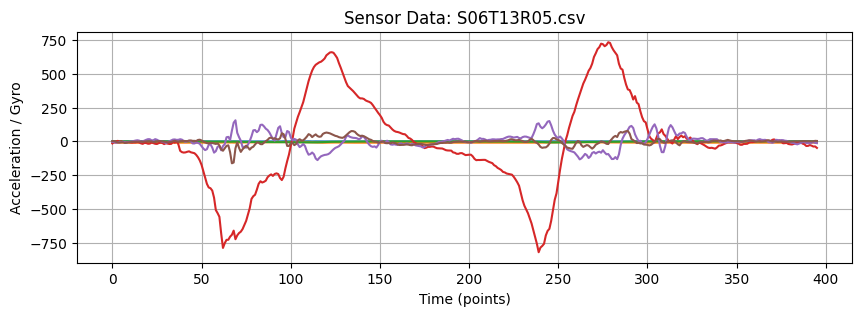

In [15]:
def predict_custom_file(filepath):
    print(f"\n Reading file: {filepath}...")
    
    if not os.path.exists(filepath):
        print(" File not found! Check your path.")
        return

    try:
        # --- 1. PREPROCESS ---
        filename = os.path.basename(filepath)
        is_kfall = filename.upper().startswith('S') and 'T' in filename.upper()
        
        if is_kfall:
            df = pd.read_csv(filepath, skiprows=1)
            data = df.iloc[:, 2:8].values * 9.8 
            new_len = int(len(data) / 2) 
            data = resample(data, new_len)
            print("   -> Detected: K-FALL format (Resampled & Converted)")
        else:
            df = pd.read_csv(filepath, header=None)
            data = df.iloc[:, 0:6].values
            print("   -> Detected: CUSTOM format (Kept as is)")

        # --- 2. WINDOWING (cutting into slices)---
        windows = []
        for i in range(0, len(data) - WINDOW_SIZE, STEP_SIZE):
            w = data[i : i + WINDOW_SIZE]
            if w.shape[0] == WINDOW_SIZE:
                windows.append(w)
        
        windows = np.array(windows) # Shape: (Num_Windows, 100, 6)
        
        if len(windows) == 0:
            print(" File is too short (less than 2 seconds). Cannot predict.")
            return

        # --- 3. PREDICT ---
        print(f"   -> Analyzed {len(windows)} windows of movement...")
        predictions = model.predict(windows, verbose=0)
        
        # --- 4. AVERAGE THE RESULTS (ave prob is 10)---
        avg_pred = np.mean(predictions, axis=0)
        final_class = np.argmax(avg_pred)
        confidence = np.max(avg_pred) * 100
        
        # --- 5. REPORT ---
        print("\n" + "="*30)
        print(f" RESULT: {LABELS[final_class]}")
        print(f" CONFIDENCE:    {confidence:.2f}%")
        print("="*30)
        
        print("Detailed Breakdown:")
        print(f"   Walking:      {avg_pred[0]*100:.1f}%")
        print(f"   Sit to Stand: {avg_pred[1]*100:.1f}%")
        print(f"   Supine to Sit:{avg_pred[2]*100:.1f}%")
        
        # --- 6. VISUALIZE ---
        plt.figure(figsize=(10, 3))
        plt.plot(data)
        plt.title(f"Sensor Data: {filename}")
        plt.xlabel("Time (points)")
        plt.ylabel("Acceleration / Gyro")
        plt.grid(True)
        plt.show()

    except Exception as e:
        print(f" Error: {e}")


predict_custom_file("Dataset/raw_sit_stand/S06T13R05.csv")

#### Converting Script

In [16]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Helper to format as C-Array
def hex_to_c_array(data, var_name="model_data"):
    c_str = '#include <cstdint>\n'
    c_str += f'const unsigned int {var_name}_len = {len(data)};\n'
    c_str += f'alignas(16) const unsigned char {var_name}[] = {{\n  '
    hex_array = [f'0x{val:02x}' for val in data]
    
    # Add newlines for readability/compatibility
    for i in range(0, len(hex_array), 12):
        c_str += ', '.join(hex_array[i:i+12])
        if i + 12 < len(hex_array): c_str += ",\n  "
            
    c_str += '\n};\n'
    return c_str

# Write to file
with open("model_data.h", "w") as f:
    f.write(hex_to_c_array(tflite_model))

print("\n SUCCESS! A new 'model_data.h' has been generated.")
print(" Download this file and put it in your Arduino folder.")

INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpz427vzio\assets


INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpz427vzio\assets



 SUCCESS! A new 'model_data.h' has been generated.
 Download this file and put it in your Arduino folder.
